# Time-Series Forecasting of Carbon Monoxide and Nitrogen Dioxide Levels

Build predictive models to forecast daily or hourly concentrations of **CO(GT)** and **NO₂(GT)** based on historical data.


In [128]:
import pandas as pd

In [129]:
url = 'https://raw.githubusercontent.com/rashakil-ds/Public-Datasets/refs/heads/main/airquality.csv'
df = pd.read_csv(url)
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,2004-03-10,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,2004-03-10,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,2004-03-10,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,2004-03-10,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


In [130]:
df.columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH'],
      dtype='object')

# Project Workflow

### **Deliverables**:
1. **Forecasting Models**:
   - Trained models for `CO(GT)` and `NO₂(GT)`.
2. **Forecast Visualization**:
   - Plots showing historical trends and future predictions.
3. **Evaluation Report**:
   - Metrics and comparison of different forecasting models.
4. **Insights and Recommendations**:
   - Suggestions for mitigating high levels of these gases based on predictions.


 <br><br><br>
 # <font color="Green"> Solution Start</font>

### 1. Data Preprocessing
- **Date-Time Parsing**:
  - Combine the `Date` and `Time` columns into a single `datetime` column.
  - Set the `datetime` column as the index of the dataset.
- **Resampling**:
  - Aggregate the data into meaningful time intervals (e.g., hourly or daily averages).
- **Handle Missing Values**:
  - Use interpolation, mean, or advanced imputation techniques to fill missing data for `CO(GT)` and `NO₂(GT)`.
- **Outlier Detection**:
  - Remove or cap extreme values in `CO(GT)` and `NO₂(GT)` using statistical thresholds.

<br><br>

## <font color='red'><li>Date-Time Parsing</li></font>

In [131]:

# Combine the Date and Time columns into a new single datetime column
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])


# Set the datetime column as the index of the dataset.
df.set_index('datetime', inplace=True)


# Drop the original Date and Time columns
df.drop(['Date', 'Time'], axis=1, inplace=True)


df.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
datetime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


## <font color='red'><li>Resampling </li></font>

In [132]:
# Resample to daily average
df_daily = df.resample('D').mean()

df_daily.head()


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
datetime,,,,,,,,,,,,,
2004-03-10,1.966667,1316.500000,86.500000,8.450000,912.333333,132.000000,1167.333333,108.833333,1545.500000,1096.000000,12.033333,54.900000,0.765633
2004-03-11,-6.187500,1244.166667,104.500000,7.979167,851.958333,130.041667,1277.250000,87.375000,1522.833333,885.250000,9.837500,64.075000,0.775767
2004-03-12,-14.095833,1281.666667,141.500000,12.129167,1008.291667,142.583333,1101.875000,89.916667,1627.291667,1084.375000,11.287500,51.095833,0.663104
2004-03-13,-5.750000,1330.666667,139.250000,10.916667,992.833333,168.416667,993.208333,105.583333,1595.791667,1245.916667,12.866667,51.533333,0.732296
2004-03-14,-5.966667,1361.125000,116.958333,9.637500,943.916667,132.166667,1001.291667,97.458333,1602.375000,1234.208333,16.012500,48.850000,0.849671


In [133]:
# Resample to hourly average
df_hourly = df.resample('H').mean()

df_hourly.head()

<ipython-input-133-2643231957>:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('H').mean()


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
datetime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


## <font color='red'><li>Handle Missing Values:</li></font>

In [134]:
# Assign CO and NO2 to a variable
gases = df_daily[['CO(GT)', 'NO2(GT)']]

# Check missing values
print(gases.isnull().sum())



CO(GT)     0
NO2(GT)    0
dtype: int64


In [135]:
# Fill missing values with interpolation
gases = gases.interpolate(method='time')

# Update the original DataFrame
df_daily[['CO(GT)', 'NO2(GT)']] = gases


gases.head()

,CO(GT),NO2(GT)
datetime,,
2004-03-10,1.966667,108.833333
2004-03-11,-6.187500,87.375000
2004-03-12,-14.095833,89.916667
2004-03-13,-5.750000,105.583333
2004-03-14,-5.966667,97.458333


## <font color='red'><li>Outlier Detection</li></font>

In [136]:
# Target columns
gases = df_daily[['CO(GT)', 'NO2(GT)']].copy()

# Outlier handling using IQR
for col in gases.columns:
    Q1 = gases[col].quantile(0.25)
    Q3 = gases[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap the outliers
    gases[col] = gases[col].clip(lower=lower_bound, upper=upper_bound)

#Update original dataframe
df_daily[['CO(GT)', 'NO2(GT)']] = gases


df_daily.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
datetime,,,,,,,,,,,,,
2004-03-10,1.966667,1316.500000,86.500000,8.450000,912.333333,132.000000,1167.333333,108.833333,1545.500000,1096.000000,12.033333,54.900000,0.765633
2004-03-11,-6.187500,1244.166667,104.500000,7.979167,851.958333,130.041667,1277.250000,87.375000,1522.833333,885.250000,9.837500,64.075000,0.775767
2004-03-12,-14.095833,1281.666667,141.500000,12.129167,1008.291667,142.583333,1101.875000,89.916667,1627.291667,1084.375000,11.287500,51.095833,0.663104
2004-03-13,-5.750000,1330.666667,139.250000,10.916667,992.833333,168.416667,993.208333,105.583333,1595.791667,1245.916667,12.866667,51.533333,0.732296
2004-03-14,-5.966667,1361.125000,116.958333,9.637500,943.916667,132.166667,1001.291667,97.458333,1602.375000,1234.208333,16.012500,48.850000,0.849671


<br><br><br>

### 2. Exploratory Data Analysis (EDA)
- **Trend Analysis**:
  - Visualize the long-term trends of `CO(GT)` and `NO₂(GT)`.
- **Seasonality**:
  - Identify seasonal patterns (e.g., daily or yearly fluctuations).
- **Correlation Analysis**:
  - Explore relationships between `CO(GT)`, `NO₂(GT)`, and other features (e.g., temperature or humidity).


## <font color='red'><li>Trend Analysis</li></font>

#### <font color='green'>Visualization (Using Matplotlib)</font>

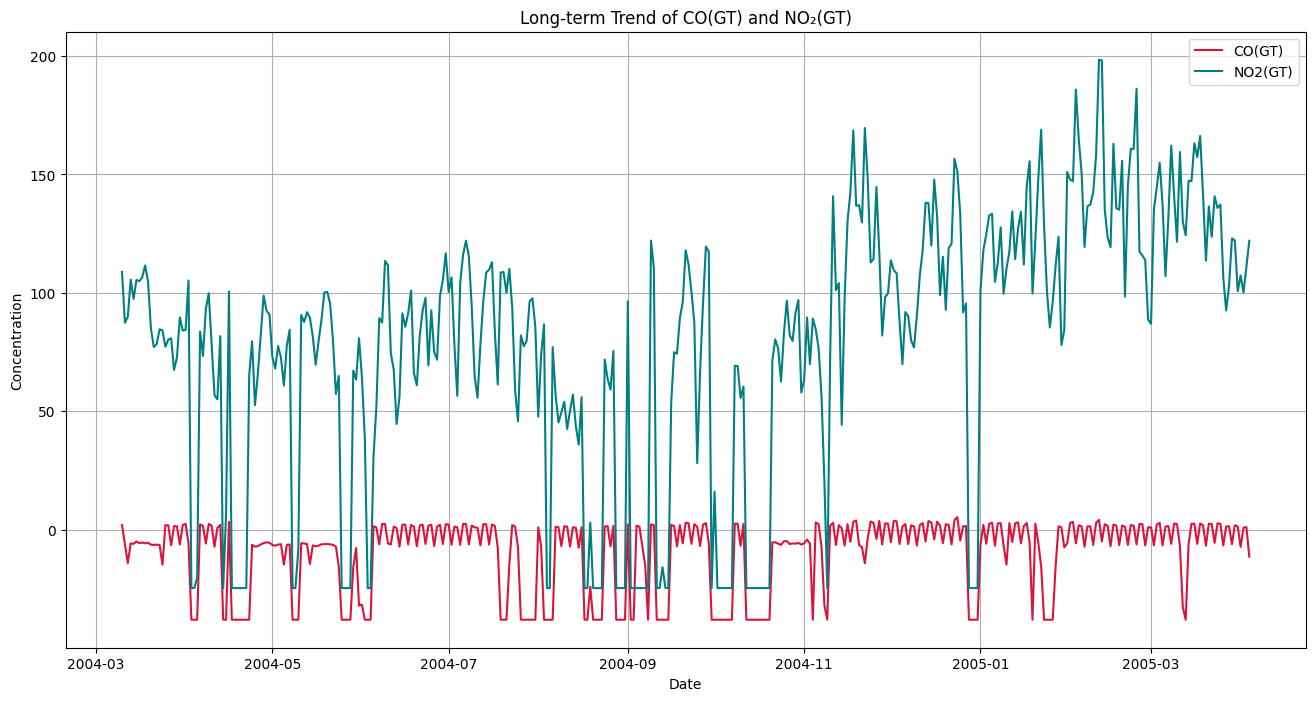

In [137]:

import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))

# Plot CO(GT)
plt.plot(df_daily.index, df_daily['CO(GT)'], label='CO(GT)', color='crimson')

# Plot NO2(GT)
plt.plot(df_daily.index, df_daily['NO2(GT)'], label='NO2(GT)', color='teal')

plt.title('Long-term Trend of CO(GT) and NO₂(GT)')
plt.xlabel('Date')
plt.ylabel('Concentration')
plt.legend()
plt.grid(True)
plt.show()


<br>

#### <font color='green'>Visualization (Using Seaborn)</font>

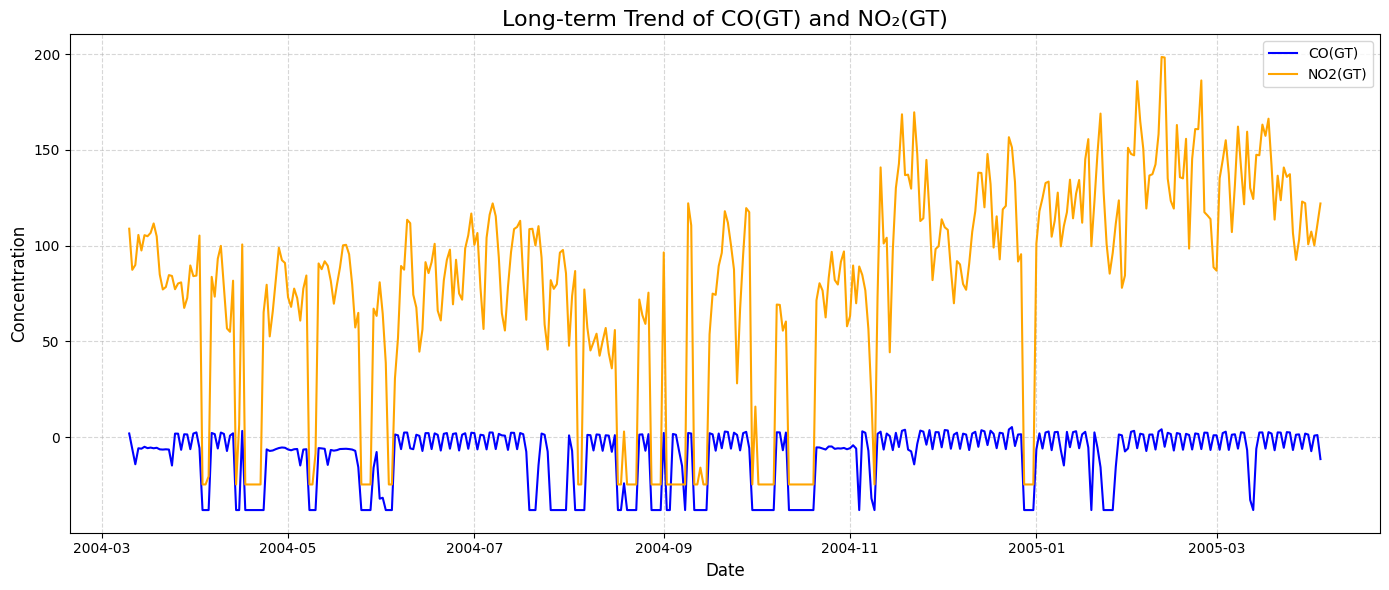

In [138]:
import seaborn as sns

# Reset index to make 'datetime' a column again for seaborn
df_plot = df_daily.reset_index()

plt.figure(figsize=(14,6))

# Plot CO(GT)
sns.lineplot(x='datetime', y='CO(GT)', data=df_plot, label='CO(GT)', color='blue')

# Plot NO2(GT)
sns.lineplot(x='datetime', y='NO2(GT)', data=df_plot, label='NO2(GT)', color='orange')

plt.title('Long-term Trend of CO(GT) and NO₂(GT)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Concentration', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## <font color='red'><li>Seasonality:</li></font>

In [139]:
## Identify seasonal patterns
df_daily['day'] = df_daily.index.day
df_daily['month'] = df_daily.index.month
df_daily['year'] = df_daily.index.year


### <font color='green'> Monthly Seasonality Plot (CO & NO₂)</font>

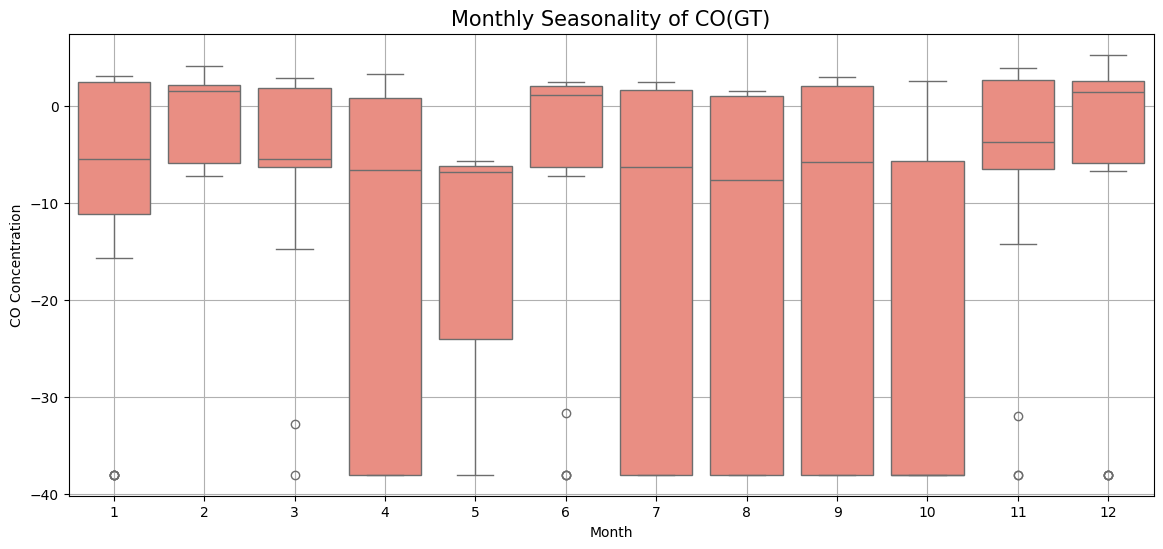

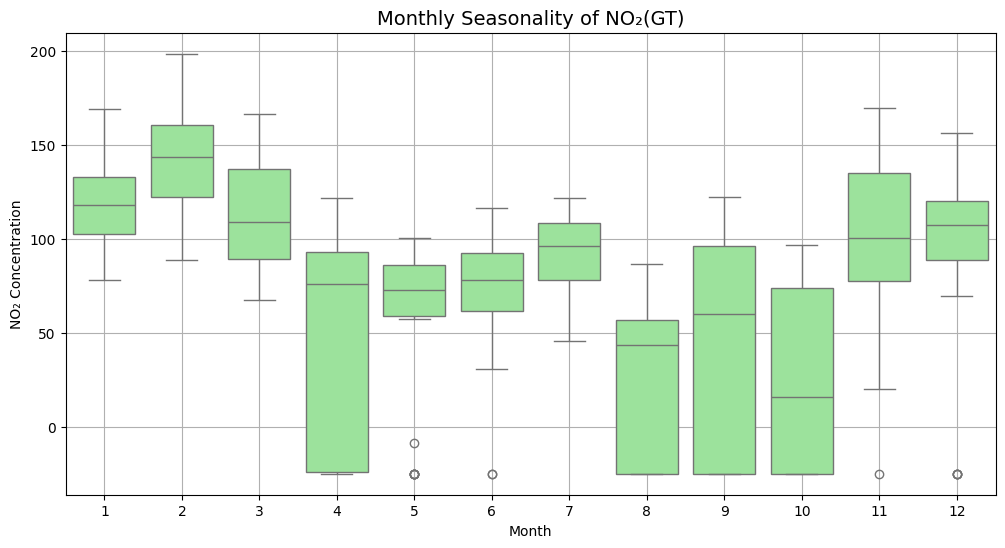

In [140]:

plt.figure(figsize=(14,6))

sns.boxplot(x='month', y='CO(GT)', data=df_daily, color='salmon')
plt.title('Monthly Seasonality of CO(GT)', fontsize=15)
plt.xlabel('Month')
plt.ylabel('CO Concentration')
plt.grid(True)
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(x='month', y='NO2(GT)', data=df_daily, color='lightgreen')
plt.title('Monthly Seasonality of NO₂(GT)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('NO₂ Concentration')
plt.grid(True)
plt.show()


### <font color='green'>Heatmap Visualization (Month vs Day)</font>

In [141]:
## average value for each (month, day) combination
co_heatmap = df_daily.groupby(['month', 'day'])['CO(GT)'].mean().unstack()
no2_heatmap = df_daily.groupby(['month', 'day'])['NO2(GT)'].mean().unstack()

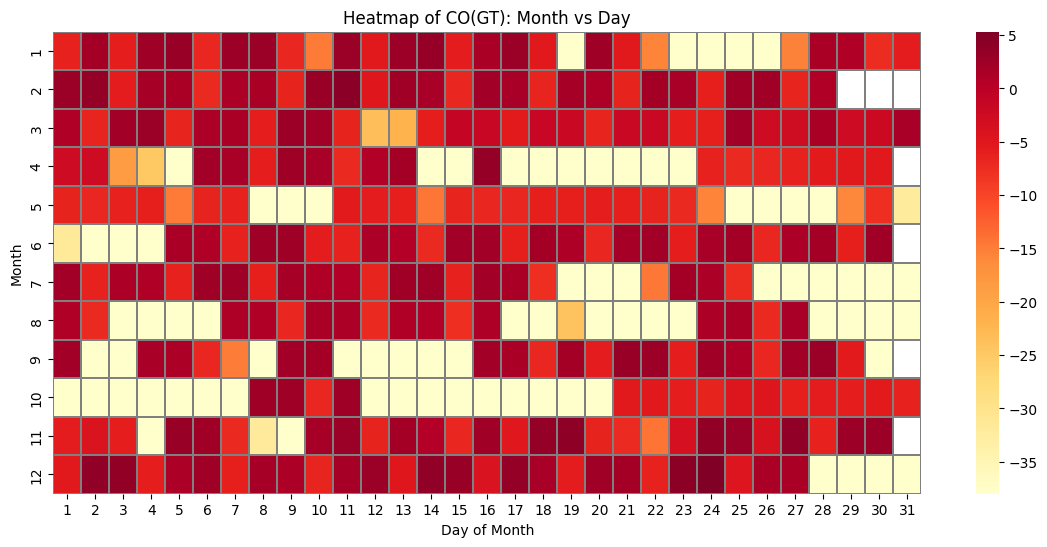

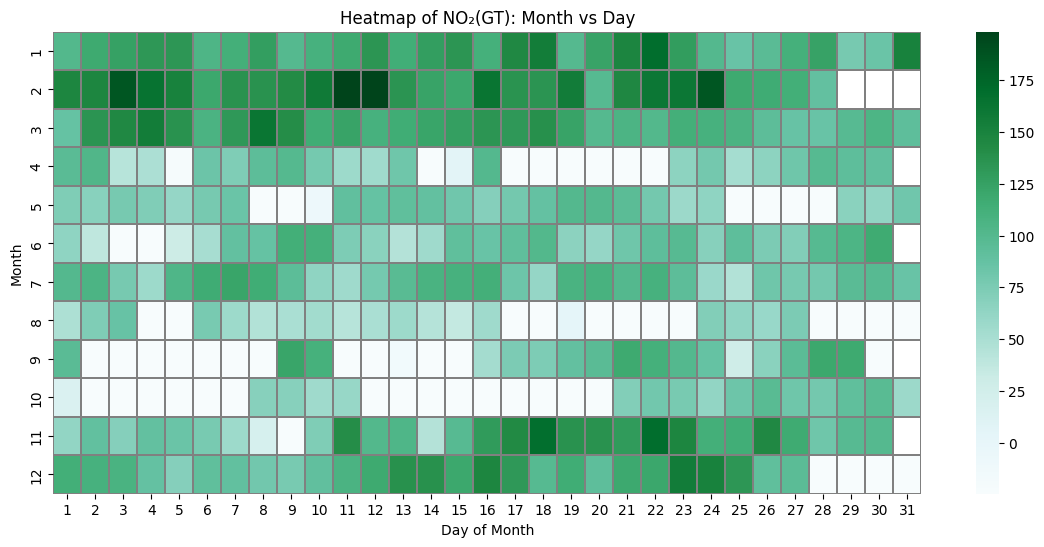

In [142]:

plt.figure(figsize=(14, 6))
sns.heatmap(co_heatmap, cmap='YlOrRd', linewidths=0.1, linecolor='gray')
plt.title('Heatmap of CO(GT): Month vs Day')
plt.xlabel('Day of Month')
plt.ylabel('Month')
plt.show()

plt.figure(figsize=(14, 6))
sns.heatmap(no2_heatmap, cmap='BuGn', linewidths=0.1, linecolor='gray')
plt.title('Heatmap of NO₂(GT): Month vs Day')
plt.xlabel('Day of Month')
plt.ylabel('Month')
plt.show()


<br>

## <font color='red'><li>Correlation Analysis </li></font>

In [143]:
## Relevant Columns check
df_daily.columns

Index(['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)',
       'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)',
       'T', 'RH', 'AH', 'day', 'month', 'year'],
      dtype='object')

In [144]:
## Correlation Matrix Calculate
correlation_matrix = df_daily[['CO(GT)', 'NO2(GT)', 'T', 'RH', 'AH']].corr()
print(correlation_matrix)

           CO(GT)   NO2(GT)         T        RH        AH
CO(GT)   1.000000  0.691235 -0.124276 -0.069966 -0.088975
NO2(GT)  0.691235  1.000000 -0.185310 -0.078273 -0.110166
T       -0.124276 -0.185310  1.000000  0.914266  0.981439
RH      -0.069966 -0.078273  0.914266  1.000000  0.960483
AH      -0.088975 -0.110166  0.981439  0.960483  1.000000


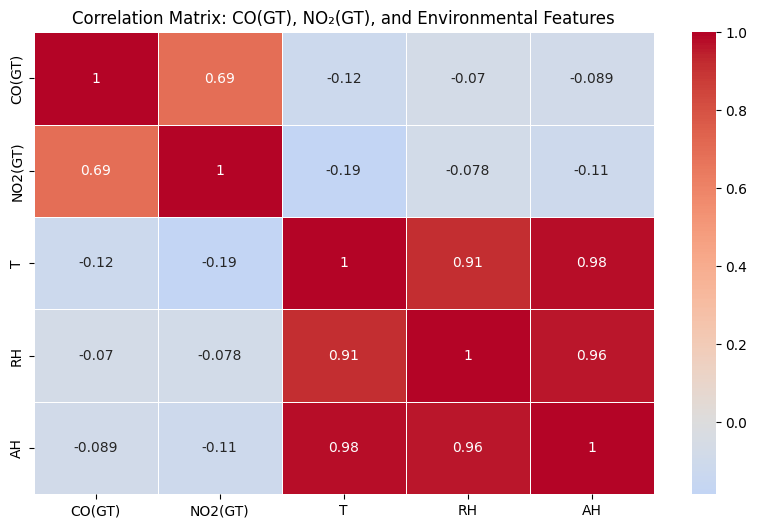

In [145]:
## Visualizetion with Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix: CO(GT), NO₂(GT), and Environmental Features')
plt.show()


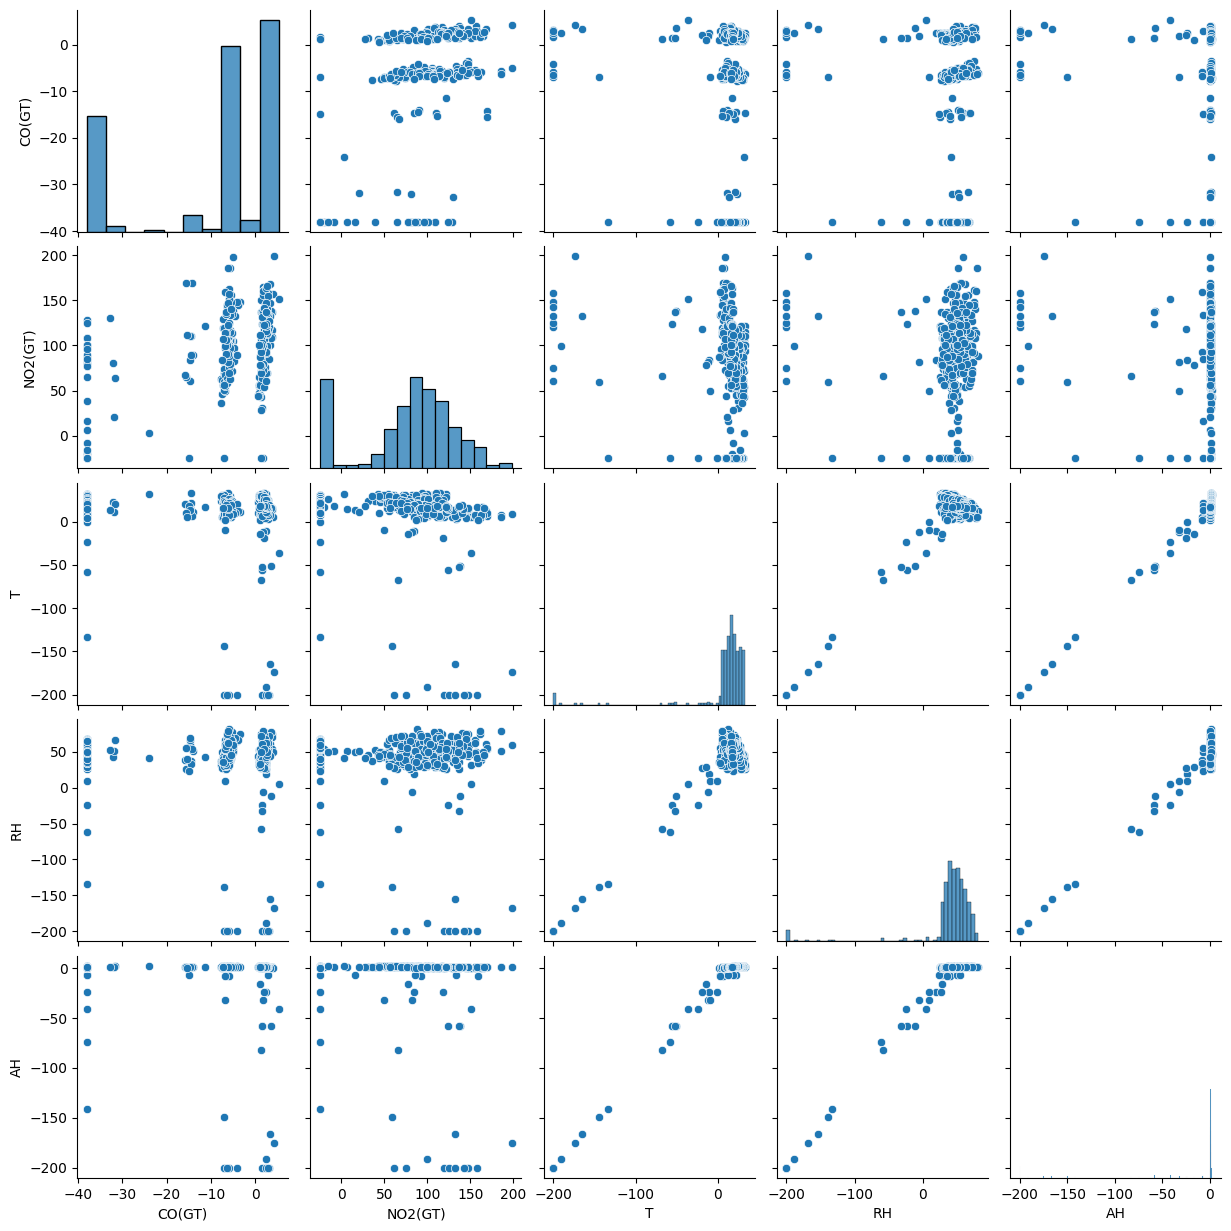

In [146]:
## Visualize with Pairplot
sns.pairplot(df_daily[['CO(GT)', 'NO2(GT)', 'T', 'RH', 'AH']])
plt.show()


<br><br><br>


### 3. Feature Engineering
- Create lag features for `CO(GT)` and `NO₂(GT)` to incorporate historical values.
- Add time-based features (e.g., hour of the day, day of the week, month).
- Include environmental factors (`T`, `RH`, `AH`) as predictors.


## <font color='red'><li>Lag Features Creation</li></font>

In [147]:
# Lag Features For 3days
for lag in range(1, 6):
    df_daily[f'CO_lag_{lag}'] = df_daily['CO(GT)'].shift(lag)
    df_daily[f'NO2_lag_{lag}'] = df_daily['NO2(GT)'].shift(lag)


In [148]:
df_daily[['CO(GT)', 'CO_lag_1', 'CO_lag_2', 'CO_lag_3',
          'NO2(GT)', 'NO2_lag_1', 'NO2_lag_2', 'NO2_lag_3']].head(10)


,CO(GT),CO_lag_1,CO_lag_2,CO_lag_3,NO2(GT),NO2_lag_1,NO2_lag_2,NO2_lag_3
datetime,,,,,,,,
2004-03-10,1.966667,NaN,NaN,NaN,108.833333,NaN,NaN,NaN
2004-03-11,-6.187500,1.966667,NaN,NaN,87.375000,108.833333,NaN,NaN
2004-03-12,-14.095833,-6.187500,1.966667,NaN,89.916667,87.375000,108.833333,NaN
2004-03-13,-5.750000,-14.095833,-6.187500,1.966667,105.583333,89.916667,87.375000,108.833333
2004-03-14,-5.966667,-5.750000,-14.095833,-6.187500,97.458333,105.583333,89.916667,87.375000
2004-03-15,-4.975000,-5.966667,-5.750000,-14.095833,105.458333,97.458333,105.583333,89.916667
2004-03-16,-5.679167,-4.975000,-5.966667,-5.750000,104.916667,105.458333,97.458333,105.583333
2004-03-17,-5.387500,-5.679167,-4.975000,-5.966667,106.625000,104.916667,105.458333,97.458333
2004-03-18,-5.745833,-5.387500,-5.679167,-4.975000,111.583333,106.625000,104.916667,105.458333


In [149]:
## For creating lag features there will be seen some NaN values so we need drop it
df_daily.dropna(inplace=True)

## <font color='red'><li>Time Based-Features Add </li></font>

In [150]:

df_daily.index = pd.to_datetime(df_daily.index)

# Time-based features
df_daily['day'] = df_daily.index.day
df_daily['month'] = df_daily.index.month
df_daily['dayofweek'] = df_daily.index.dayofweek
df_daily['is_weekend'] = df_daily['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)


## Show some values
df_daily[['CO(GT)', 'NO2(GT)', 'day', 'month', 'dayofweek', 'is_weekend']].head()


,CO(GT),NO2(GT),day,month,dayofweek,is_weekend
datetime,,,,,,
2004-03-15,-4.975000,105.458333,15,3,0,0
2004-03-16,-5.679167,104.916667,16,3,1,0
2004-03-17,-5.387500,106.625000,17,3,2,0
2004-03-18,-5.745833,111.583333,18,3,3,0
2004-03-19,-5.491667,104.833333,19,3,4,0


## <font color='red'><li>Include Environmental Features</li></font>

In [151]:
## Relavant columns features retain
predictors = [
    'CO(GT)', 'NO2(GT)', 'T', 'RH', 'AH',
    'CO_lag_1', 'CO_lag_2', 'CO_lag_3',
    'NO2_lag_1', 'NO2_lag_2', 'NO2_lag_3',
    'day', 'month', 'dayofweek', 'is_weekend'
]

# All values are set in the final feature
df_model = df_daily[predictors].copy()


df_model.head()


,CO(GT),NO2(GT),T,RH,AH,CO_lag_1,CO_lag_2,CO_lag_3,NO2_lag_1,NO2_lag_2,NO2_lag_3,day,month,dayofweek,is_weekend
datetime,,,,,,,,,,,,,,,
2004-03-15,-4.975000,105.458333,17.366667,50.320833,0.944029,-5.966667,-5.750000,-14.095833,97.458333,105.583333,89.916667,15,3,0,0
2004-03-16,-5.679167,104.916667,18.625000,44.837500,0.871021,-4.975000,-5.966667,-5.750000,105.458333,97.458333,105.583333,16,3,1,0
2004-03-17,-5.387500,106.625000,18.779167,41.166667,0.804917,-5.679167,-4.975000,-5.966667,104.916667,105.458333,97.458333,17,3,2,0
2004-03-18,-5.745833,111.583333,17.762500,44.087500,0.826017,-5.387500,-5.679167,-4.975000,106.625000,104.916667,105.458333,18,3,3,0
2004-03-19,-5.491667,104.833333,14.191667,57.904167,0.923958,-5.745833,-5.387500,-5.679167,111.583333,106.625000,104.916667,19,3,4,0


<br><br><br>

### 4. Time-Series Forecasting
- Train separate models for **CO(GT)** and **NO₂(GT)**.
- Explore the following forecasting approaches:
  - **Statistical Models**:
    - Classical models like ARIMA or SARIMA for univariate forecasting.
  - **Machine Learning Models**:
    - Use regression models trained on lag features and external predictors.
  - **Deep Learning Models**:
    - Apply LSTM, GRU, or other RNN-based models for sequence forecasting.
- Evaluate and compare the models.


## <font color='red'><li>Train separate models for CO(GT) and NO₂(GT).</li></font>

In [152]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# ====== Features & Targets ======

# CO prediction features
features_co = [
    'CO_lag_1', 'CO_lag_2', 'CO_lag_3', 'T', 'RH', 'AH',
    'day', 'month', 'dayofweek', 'is_weekend'
]
target_co = 'CO(GT)'

# NO2 prediction features
features_no2 = [
    'NO2_lag_1', 'NO2_lag_2', 'NO2_lag_3', 'T', 'RH', 'AH',
    'day', 'month', 'dayofweek', 'is_weekend'
]
target_no2 = 'NO2(GT)'

# ====== Train-test split ======

X_co = df_model[features_co]
y_co = df_model[target_co]
X_train_co, X_test_co, y_train_co, y_test_co = train_test_split(X_co, y_co, test_size=0.2, random_state=42)

X_no2 = df_model[features_no2]
y_no2 = df_model[target_no2]
X_train_no2, X_test_no2, y_train_no2, y_test_no2 = train_test_split(X_no2, y_no2, test_size=0.2, random_state=42)

# ====== Model training ======

model_co = RandomForestRegressor(random_state=42)
model_co.fit(X_train_co, y_train_co)

model_no2 = RandomForestRegressor(random_state=42)
model_no2.fit(X_train_no2, y_train_no2)

# ====== Predictions ======

y_pred_co = model_co.predict(X_test_co)
y_pred_no2 = model_no2.predict(X_test_no2)


## <font color='red'><li>Statistical Models (ARIMA/SARIMA) — Univariate Forecasting</li></font>

In [153]:
import statsmodels.api as sm

# Split train-test (example: last 20% for test)
n = len(df_model)
train_size = int(n * 0.8)

# CO(GT)
train_co = df_model['CO(GT)'].iloc[:train_size]
test_co = df_model['CO(GT)'].iloc[train_size:]

# Fit ARIMA (p,d,q) params can be tuned via auto_arima (not shown here)
model_co_arima = sm.tsa.arima.ARIMA(train_co, order=(5,1,0))
model_co_fit = model_co_arima.fit()

# Forecast
forecast_co = model_co_fit.forecast(steps=len(test_co))

# Similarly for NO2(GT)
train_no2 = df_model['NO2(GT)'].iloc[:train_size]
test_no2 = df_model['NO2(GT)'].iloc[train_size:]

model_no2_arima = sm.tsa.arima.ARIMA(train_no2, order=(5,1,0))
model_no2_fit = model_no2_arima.fit()

forecast_no2 = model_no2_fit.forecast(steps=len(test_no2))


## <font color='red'><li>Machine Learning Models</li></font>

In [154]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

features_co = [
    'CO_lag_1', 'CO_lag_2', 'CO_lag_3', 'T', 'RH', 'AH',
    'day', 'month', 'dayofweek', 'is_weekend'
]
features_no2 = [
    'NO2_lag_1', 'NO2_lag_2', 'NO2_lag_3', 'T', 'RH', 'AH',
    'day', 'month', 'dayofweek', 'is_weekend'
]

X_co = df_model[features_co]
y_co = df_model['CO(GT)']
X_no2 = df_model[features_no2]
y_no2 = df_model['NO2(GT)']

# Split train-test
from sklearn.model_selection import train_test_split
X_train_co, X_test_co, y_train_co, y_test_co = train_test_split(X_co, y_co, test_size=0.2, random_state=42)
X_train_no2, X_test_no2, y_train_no2, y_test_no2 = train_test_split(X_no2, y_no2, test_size=0.2, random_state=42)

# Train RandomForest
model_co_rf = RandomForestRegressor(random_state=42)
model_co_rf.fit(X_train_co, y_train_co)
y_pred_co_rf = model_co_rf.predict(X_test_co)

model_no2_rf = RandomForestRegressor(random_state=42)
model_no2_rf.fit(X_train_no2, y_train_no2)
y_pred_no2_rf = model_no2_rf.predict(X_test_no2)


## <font color='red'><li>Deep Learning Models (LSTM)</li></font>

In [163]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

# Prepare data for sequence models (LSTM/GRU)
def create_sequences(data, target_col, seq_length=3):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data.iloc[i:i+seq_length].values)
        y.append(data[target_col].iloc[i+seq_length])
    return np.array(X), np.array(y)

# Select features for DL model (lag features + time + env)
features_dl_co = features_co
features_dl_no2 = features_no2

# Scale features
scaler_co = MinMaxScaler()
scaler_no2 = MinMaxScaler()

df_co_scaled = pd.DataFrame(scaler_co.fit_transform(df_model[features_dl_co]), columns=features_dl_co)
df_no2_scaled = pd.DataFrame(scaler_no2.fit_transform(df_model[features_dl_no2]), columns=features_dl_no2)

# Create sequences for CO(GT)
seq_length = 3
X_co_seq, y_co_seq = create_sequences(df_co_scaled, 'CO_lag_1', seq_length)  # lag_1 as proxy target

# Train-test split for CO
train_size = int(0.8 * len(X_co_seq))
X_train_co, X_test_co = X_co_seq[:train_size], X_co_seq[train_size:]
y_train_co, y_test_co = y_co_seq[:train_size], y_co_seq[train_size:]

# Build and train LSTM model for CO
model_co_lstm = Sequential([
    LSTM(32, activation='relu', input_shape=(seq_length, len(features_dl_co))),
    Dropout(0.2),
    Dense(1)
])
model_co_lstm.compile(optimizer='adam', loss='mse')
model_co_lstm.fit(X_train_co, y_train_co, epochs=50, batch_size=32, verbose=0)

# Build and train GRU model for CO
model_co_gru = Sequential([
    GRU(32, activation='relu', input_shape=(seq_length, len(features_dl_co))),
    Dropout(0.2),
    Dense(1)
])
model_co_gru.compile(optimizer='adam', loss='mse')
model_co_gru.fit(X_train_co, y_train_co, epochs=100, batch_size=64,verbose=0)

# Predict using LSTM and GRU models for CO
y_pred_co_lstm = model_co_lstm.predict(X_test_co)
y_pred_co_gru = model_co_gru.predict(X_test_co)




# Create sequences for NO2(GT)
X_no2_seq, y_no2_seq = create_sequences(df_no2_scaled, 'NO2_lag_1', seq_length)

# Train-test split for NO2
train_size_no2 = int(0.8 * len(X_no2_seq))
X_train_no2, X_test_no2 = X_no2_seq[:train_size_no2], X_no2_seq[train_size_no2:]
y_train_no2, y_test_no2 = y_no2_seq[:train_size_no2], y_no2_seq[train_size_no2:]

# Build and train LSTM model for NO2
model_no2_lstm = Sequential([
    LSTM(64, activation='relu', input_shape=(seq_length, len(features_dl_no2))),
    Dropout(0.2),
    Dense(1)
])
model_no2_lstm.compile(optimizer='adam', loss='mse')
model_no2_lstm.fit(X_train_no2, y_train_no2, epochs=100, batch_size=64, verbose=0)

# Build and train GRU model for NO2
model_no2_gru = Sequential([
    GRU(64, activation='relu', input_shape=(seq_length, len(features_dl_no2))),
    Dropout(0.2),
    Dense(1)
])
model_no2_gru.compile(optimizer='adam', loss='mse')
model_no2_gru.fit(X_train_no2, y_train_no2, epochs=100, batch_size=64, verbose=0)

# Predict using LSTM and GRU models for NO2
y_pred_no2_lstm = model_no2_lstm.predict(X_test_no2)
y_pred_no2_gru = model_no2_gru.predict(X_test_no2)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


## <font color='red'><li> Evaluation & Comparison</li></font>

In [164]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} -> RMSE: {rmse:.4f}, R2: {r2:.4f}")

def evaluate_with_trim(y_true, y_pred, model_name):
    min_len = min(len(y_true), len(y_pred))
    evaluate(y_true[:min_len], y_pred[:min_len], model_name)

# --- Statistical models ---
evaluate_with_trim(test_co, forecast_co, "ARIMA CO(GT)")
evaluate_with_trim(test_no2, forecast_no2, "ARIMA NO2(GT)")

# --- Machine Learning models ---
evaluate_with_trim(y_test_co, y_pred_co_rf, "RandomForest CO(GT)")
evaluate_with_trim(y_test_no2, y_pred_no2_rf, "RandomForest NO2(GT)")

# --- Deep Learning models ---

# CO(GT)
evaluate_with_trim(y_test_co, y_pred_co_lstm.flatten(), "LSTM CO(GT)")
evaluate_with_trim(y_test_co, y_pred_co_gru.flatten(), "GRU CO(GT)")

# NO2(GT)
evaluate_with_trim(y_test_no2, y_pred_no2_lstm.flatten(), "LSTM NO2(GT)")
evaluate_with_trim(y_test_no2, y_pred_no2_gru.flatten(), "GRU NO2(GT)")


ARIMA CO(GT) -> RMSE: 12.2600, R2: -0.1957
ARIMA NO2(GT) -> RMSE: 29.8645, R2: -0.2796
RandomForest CO(GT) -> RMSE: 15.8248, R2: -3706.2810
RandomForest NO2(GT) -> RMSE: 89.9103, R2: -571066.6162
LSTM CO(GT) -> RMSE: 0.2294, R2: 0.2208
GRU CO(GT) -> RMSE: 0.2171, R2: 0.3020
LSTM NO2(GT) -> RMSE: 0.1273, R2: -0.1446
GRU NO2(GT) -> RMSE: 0.1198, R2: -0.0145


<br><br><br>

### 5. Model Evaluation
- Use appropriate metrics for forecasting:
  - Mean Absolute Error (MAE)
  - Root Mean Squared Error (RMSE)
  - Mean Absolute Percentage Error (MAPE)
- Plot actual vs. predicted values to visualize performance.


## <font color='red'><li>Use appropriate metrics for forecasting</li></font>

In [165]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Zero division avoid small value add
    epsilon = 1e-10
    return np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

def evaluate_forecast(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    print(f"{model_name} Metrics:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAPE: {mape:.2f}%")


def evaluate_with_trim(y_true, y_pred, model_name):
    min_len = min(len(y_true), len(y_pred))
    evaluate_forecast(y_true[:min_len], y_pred[:min_len], model_name)

# calling the model evaluation
evaluate_with_trim(y_test_co, y_pred_co_lstm.flatten(), "LSTM CO(GT)")
evaluate_with_trim(y_test_co, y_pred_co_gru.flatten(), "GRU CO(GT)")
evaluate_with_trim(y_test_no2, y_pred_no2_lstm.flatten(), "LSTM NO2(GT)")
evaluate_with_trim(y_test_no2, y_pred_no2_gru.flatten(), "GRU NO2(GT)")


LSTM CO(GT) Metrics:
  MAE:  0.1759
  RMSE: 0.2294
  MAPE: 28854891293.47%
GRU CO(GT) Metrics:
  MAE:  0.1588
  RMSE: 0.2171
  MAPE: 30101901739.27%
LSTM NO2(GT) Metrics:
  MAE:  0.0959
  RMSE: 0.1273
  MAPE: 13.95%
GRU NO2(GT) Metrics:
  MAE:  0.0973
  RMSE: 0.1198
  MAPE: 13.63%


**Note: I've got an unreliable value for MAPE so I fix it**
### Fixed Evaluation Functions:

In [166]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Fixed MAPE (ignores zero targets)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    if np.sum(mask) == 0:
        return np.nan  # avoid divide-by-zero
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# SMAPE (Symmetric MAPE)
def symmetric_mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) + 1e-10  # Avoid divide by 0
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / denominator)

# Combined Evaluation Function
def evaluate_forecast_fixed(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    smape = symmetric_mean_absolute_percentage_error(y_true, y_pred)

    print(f"{model_name} Metrics:")
    print(f"  MAE   : {mae:.4f}")
    print(f"  RMSE  : {rmse:.4f}")
    print(f"  MAPE  : {mape:.2f}%")
    print(f"  SMAPE : {smape:.2f}%\n")


In [167]:
evaluate_forecast_fixed(y_test_co, y_pred_co_lstm.flatten(), "LSTM CO(GT)")
evaluate_forecast_fixed(y_test_co, y_pred_co_gru.flatten(), "GRU CO(GT)")

evaluate_forecast_fixed(y_test_no2, y_pred_no2_lstm.flatten(), "LSTM NO₂(GT)")
evaluate_forecast_fixed(y_test_no2, y_pred_no2_gru.flatten(), "GRU NO₂(GT)")


LSTM CO(GT) Metrics:
  MAE   : 0.1759
  RMSE  : 0.2294
  MAPE  : 24.60%
  SMAPE : 36.19%

GRU CO(GT) Metrics:
  MAE   : 0.1588
  RMSE  : 0.2171
  MAPE  : 22.47%
  SMAPE : 33.92%

LSTM NO₂(GT) Metrics:
  MAE   : 0.0959
  RMSE  : 0.1273
  MAPE  : 13.95%
  SMAPE : 14.02%

GRU NO₂(GT) Metrics:
  MAE   : 0.0973
  RMSE  : 0.1198
  MAPE  : 13.63%
  SMAPE : 14.53%




## <font color='red'><li>Plot actual vs. predicted values to visualize performance.</li></font>

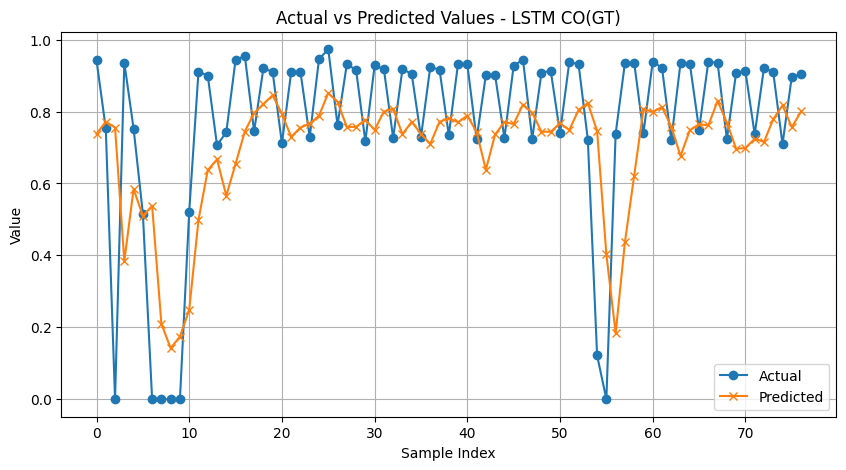

In [168]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

def plot_actual_vs_predicted(y_true, y_pred, model_name):
    plt.figure(figsize=(10,5))
    plt.plot(y_true, label='Actual', marker='o')
    plt.plot(y_pred, label='Predicted', marker='x')
    plt.title(f'Actual vs Predicted Values - {model_name}')
    plt.xlabel('Sample Index')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.show()
plot_actual_vs_predicted(y_test_co, y_pred_co_lstm.flatten(), "LSTM CO(GT)")


<br><br><br>

### 6. Visualization and Insights
- Generate forecasts for future dates and visualize the trends.
- Highlight seasonal patterns, peak times, and periods of concern.
- Provide actionable recommendations based on predicted trends.




## <font color='red'><li>Generate Future Forecasts (e.g. Next 7 Days)
</li></font>

In [180]:
# ধরো daily frequency, last date থেকে 7 দিন পর পর্যন্ত forecast করবো
future_steps = 7
last_date = df_daily.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=future_steps, freq='D')


In [181]:
def forecast_future(model, data_scaled, scaler, features, seq_length, future_steps):
    # data_scaled : scaled dataframe of features (last available data)
    # model : trained LSTM/GRU model
    # scaler : fitted scaler to inverse transform later
    # features : features list for model input
    # seq_length : input sequence length of model
    # future_steps : how many future steps to forecast

    last_seq = data_scaled[-seq_length:].values  # last seq_length rows as initial input
    preds = []

    for _ in range(future_steps):
        X_input = last_seq.reshape((1, seq_length, len(features)))
        yhat = model.predict(X_input)[0][0]
        preds.append(yhat)

        # Update last_seq by appending new prediction and removing first timestep
        new_row = np.append([yhat], last_seq[-1,1:])  # shift values: here assuming target first column
        last_seq = np.vstack([last_seq[1:], new_row])

    # Inverse scale predicted target only
    preds = np.array(preds).reshape(-1,1)
    dummy = np.zeros((future_steps, len(features)))
    dummy[:,0] = preds.flatten()  # assuming target is first feature, adjust if needed
    inv_preds = scaler.inverse_transform(dummy)[:,0]

    return inv_preds


In [182]:

future_steps = 7  # next seven days forecast
last_date = df_daily.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=future_steps, freq='D')

# CO(GT) forecast (LSTM model example)
future_co = forecast_future(model_co_lstm, df_co_scaled[features_dl_co], scaler_co, features_dl_co, seq_length, future_steps)

# NO2(GT) forecast (GRU model example)
future_no2 = forecast_future(model_no2_gru, df_no2_scaled[features_dl_no2], scaler_no2, features_dl_no2, seq_length, future_steps)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step



## <font color='red'><li>Visualize Historical + Forecasted Trends</li></font>

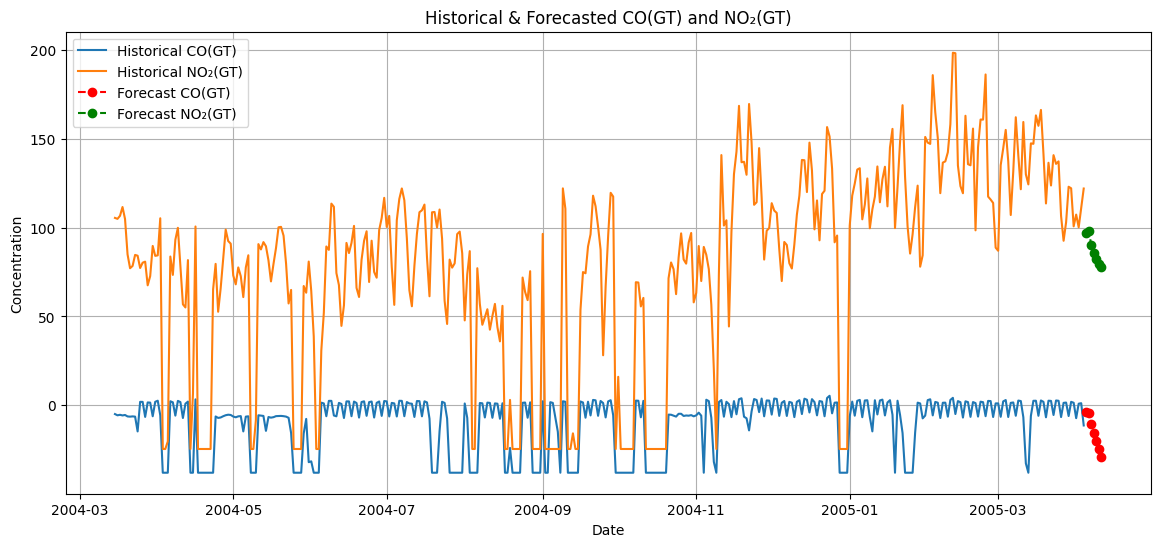

In [183]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# Plot Historical
plt.plot(df_daily.index, df_daily['CO(GT)'], label='Historical CO(GT)')
plt.plot(df_daily.index, df_daily['NO2(GT)'], label='Historical NO₂(GT)')

# Plot Forecast
plt.plot(future_dates, future_co, 'r--o', label='Forecast CO(GT)')
plt.plot(future_dates, future_no2, 'g--o', label='Forecast NO₂(GT)')

plt.title("Historical & Forecasted CO(GT) and NO₂(GT)")
plt.xlabel("Date")
plt.ylabel("Concentration")
plt.legend()
plt.grid(True)
plt.show()


## <font color='red'><li>Highlight Seasonal Patterns & Peak Times</li></font>

<ipython-input-184-2403858874>:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = df_daily[['CO(GT)', 'NO2(GT)']].resample('M').mean()


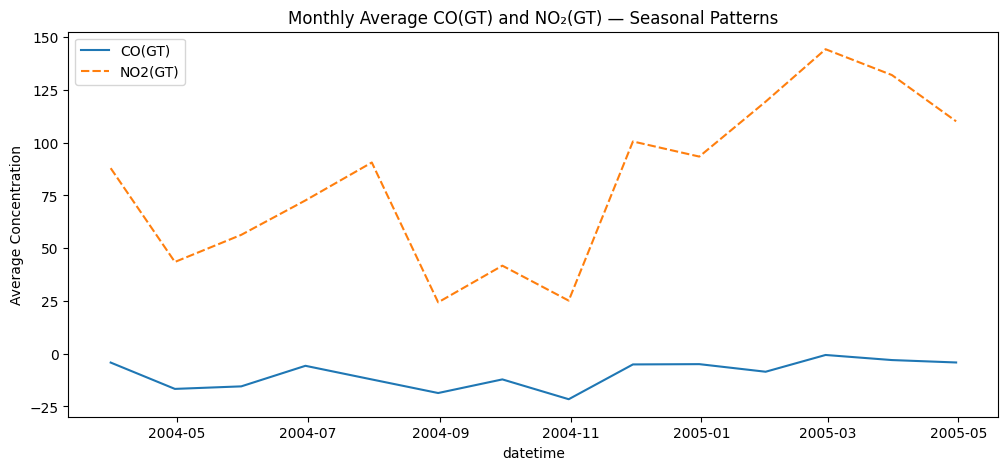

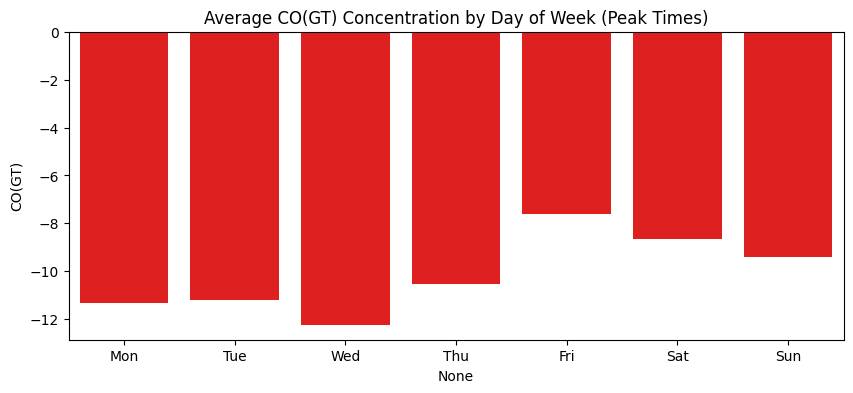

In [184]:
import seaborn as sns

# Monthly average to check seasonality
monthly_avg = df_daily[['CO(GT)', 'NO2(GT)']].resample('M').mean()

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_avg)
plt.title("Monthly Average CO(GT) and NO₂(GT) — Seasonal Patterns")
plt.ylabel("Average Concentration")
plt.show()

# Peak day of week (weekday pattern)
weekday_avg = df_daily[['CO(GT)', 'NO2(GT)']].groupby(df_daily.index.dayofweek).mean()
weekday_avg.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(10,4))
sns.barplot(x=weekday_avg.index, y=weekday_avg['CO(GT)'], color='r')
plt.title("Average CO(GT) Concentration by Day of Week (Peak Times)")
plt.show()




## <font color='red'><li> Provide Actionable Recommendations:</li></font>
<br><br>

### Recommendations based on predicted trends:

- **High CO(GT) levels on weekdays (e.g., Monday-Friday):**
  - Encourage public transportation and carpooling during peak traffic hours.
  - Promote use of cleaner fuels and electric vehicles.

- **Seasonal peaks in colder months (winter):**
  - Increase air quality monitoring during these months.
  - Advocate for reduced industrial emissions and proper heating methods.

- **Rising NO₂(GT) trends predicted:**
  - Implement stricter vehicle emission regulations.
  - Increase green zones and tree plantation in urban areas.

- **General suggestions:**
  - Raise public awareness about air pollution health risks.
  - Encourage teleworking/flexible hours to reduce rush hour traffic.

